In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
config_path = "/home/dnanexus/ukbgym/config.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

rare_variant_annotations = config["rare_variant_annotations"]

all_annotation_list = []
color_dict = {}
label_dict = {}
direction_dict = {}

# Optional: for a Polars DataFrame
annotations = []
annotation_colors = []
annotation_labels = []
annotation_dirs = []

for category, annos in rare_variant_annotations.items():
    for anno, props in annos.items():
        # validate presence of keys
        if "color" not in props or "label" not in props:
            raise ValueError(
                f"Annotation '{anno}' in category '{category}' must define both 'color' and 'label'."
            )

        # Save lists/dicts
        all_annotation_list.append(anno)
        color_dict[anno] = props["color"]
        label_dict[anno] = props["label"]
        direction = props.get("direction", 1)
        direction_dict[anno] = direction

        # For Polars DataFrame
        annotations.append(anno)
        annotation_colors.append(props["color"])
        annotation_labels.append(props["label"])
        annotation_dirs.append(direction)

# Create Polars DataFrame
anno_config_df = pl.DataFrame({
    "annotation": annotations,
    "annotation_dir": annotation_dirs,
    "color": annotation_colors,
    "label": annotation_labels
})

print("Annotations:", all_annotation_list)
print("Colors:", color_dict)
print("Labels:", label_dict)
print("Directions:", direction_dict)
print("\nPolars DataFrame:")
print(anno_config_df)


Annotations: ['cadd_raw', 'am_pathogenicity', 'esmscoremissense', 'gpn_score', 'zooverphylop', 'verphylop', 'relative_cds_position']
Colors: {'cadd_raw': '#1f77b4', 'am_pathogenicity': '#e76e5b', 'esmscoremissense': '#feb72d', 'gpn_score': '#942c80', 'zooverphylop': '#6a1c81', 'verphylop': '#440154', 'relative_cds_position': '#b5de2b'}
Labels: {'cadd_raw': 'CADD Raw', 'am_pathogenicity': 'AlphaMissense', 'esmscoremissense': 'ESM1v', 'gpn_score': 'GPN-MSA', 'zooverphylop': 'Zoonomia vertebrate\nPhyloP', 'verphylop': 'Vertebrate PhyloP', 'relative_cds_position': 'Relative CDS\nPosition'}
Directions: {'cadd_raw': 1, 'am_pathogenicity': 1, 'esmscoremissense': -1, 'gpn_score': -1, 'zooverphylop': 1, 'verphylop': 1, 'relative_cds_position': -1}

Polars DataFrame:
shape: (7, 4)
┌───────────────────────┬────────────────┬─────────┬─────────────────────┐
│ annotation            ┆ annotation_dir ┆ color   ┆ label               │
│ ---                   ┆ ---            ┆ ---     ┆ ---            

In [4]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6coding.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [5]:
anno = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.with_columns(
    (pl.col('consequence_missense_variant') == 1)
).select(
    set(['id', 'region']).union(set(existing_annos))
).filter(
    pl.col('id').is_in(appv['id'].unique())
)

melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
    # pl.col("af_ukb").cast(pl.Float32)
)

melted_anno

/tmp/ipykernel_315424/1718422457.py:9: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score
str,str,str,f32
"""chr1:169795116:G:C""","""ENSG00000000460""","""cadd_raw""",2.172202
"""chr1:169798959:G:A""","""ENSG00000000460""","""cadd_raw""",6.18842
"""chr1:169798959:G:GT""","""ENSG00000000460""","""cadd_raw""",0.0
"""chr1:169798959:G:T""","""ENSG00000000460""","""cadd_raw""",5.926235
"""chr1:169800908:G:A""","""ENSG00000000460""","""cadd_raw""",3.04392
…,…,…,…
"""chr7:151061964:A:G""","""ENSG00000288608""","""relative_cds_position""",0.73
"""chr7:151061966:C:T""","""ENSG00000288608""","""relative_cds_position""",0.76
"""chr7:151061967:GA:G""","""ENSG00000288608""","""relative_cds_position""",0.8


In [6]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(appv['phenotype'].unique())) &
    (pl.col('region').is_in(anno['region'].unique()))
)

# Keep the top hit per gene
# a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)

gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner').with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)

gene_trait_df

/tmp/ipykernel_315424/462737203.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000151414""","""ENSG00000151414""","""NEK7""","""lymphocyte_percentage_int""","""continuous""",-0.34187,-1.0
"""ENSG00000068976""","""ENSG00000068976""","""PYGM""","""lymphocyte_percentage_int""","""continuous""",0.0320271,1.0
"""ENSG00000160593""","""ENSG00000160593""","""JAML""","""lymphocyte_percentage_int""","""continuous""",0.189942,1.0
"""ENSG00000173575""","""ENSG00000173575""","""CHD2""","""lymphocyte_percentage_int""","""continuous""",0.0271693,1.0
"""ENSG00000240505""","""ENSG00000240505""","""TNFRSF13B""","""lymphocyte_percentage_int""","""continuous""",-0.059283,-1.0
…,…,…,…,…,…,…
"""ENSG00000162337""","""ENSG00000162337""","""LRP5""","""heel_bone_mineral_density_bmd_…","""continuous""",-0.794196,-1.0
"""ENSG00000125084""","""ENSG00000125084""","""WNT1""","""heel_bone_mineral_density_bmd_…","""continuous""",-0.483304,-1.0
"""ENSG00000137834""","""ENSG00000137834""","""SMAD6""","""heel_bone_mineral_density_bmd_…","""continuous""",-0.43297,-1.0


In [7]:
# Filter annotations and appv to those in gene_trait_df
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

# Join df all the dataframes with pairs to restrict to valid 
pheno_anno = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .collect(engine='streaming')
)

print(pheno_anno.shape)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value', 'annotation_score']
]

# Apply the window expressions with .with_columns()
pheno_anno = pheno_anno.with_columns(rank_expressions)

/tmp/ipykernel_315424/3381029561.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_315424/3381029561.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


(5404287, 4) (82315973, 4)
(17087623, 12)


In [8]:
correlation_df = (
    pheno_anno
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr(pl.col("mean_pheno_value_rank"), pl.col("annotation_score_rank")).alias("correlation")
    ).with_columns(
        pl.col("correlation").abs().alias("abs_corr"),
    )
)

# Check if the variant counts are consistent within each (region, phenotype) pair
inconsistent = (
    correlation_df
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {inconsistent.shape[0]}")

# Join with beta directions and annotation directions
correlation_df = correlation_df.join(
    gene_trait_df[['region', 'phenotype', 'beta', 'beta_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
).with_columns(
    (pl.col('correlation')*pl.col('beta_dir')*pl.col('annotation_dir')).alias('corr_beta')
)
correlation_df

Inconsistent (region, phenotype) pairs: 0


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr,beta,beta_dir,annotation_dir,color,label,corr_beta
str,str,str,str,u64,f64,f64,f64,f64,i64,str,str,f64
"""ENSG00000204525""","""HLA-C""","""neutrophill_count_int""","""gpn_score""",213,0.188563,0.188563,0.102357,1.0,-1,"""#942c80""","""GPN-MSA""",-0.188563
"""ENSG00000196712""","""NF1""","""neutrophill_percentage_int""","""esmscoremissense""",1605,0.00558,0.00558,0.658181,1.0,-1,"""#feb72d""","""ESM1v""",-0.00558
"""ENSG00000128567""","""PODXL""","""microalbumin_in_urine_int""","""zooverphylop""",247,0.043607,0.043607,0.798281,1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",0.043607
"""ENSG00000143365""","""RORC""","""gamma_glutamyltransferase_int""","""zooverphylop""",323,0.021184,0.021184,0.240319,1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",0.021184
"""ENSG00000198569""","""SLC34A3""","""urea_int""","""gpn_score""",613,-0.122504,0.122504,0.198031,1.0,-1,"""#942c80""","""GPN-MSA""",0.122504
…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000007255""","""TRAPPC6A""","""apolipoprotein_a_int""","""gpn_score""",302,-0.015407,0.015407,0.0267531,1.0,-1,"""#942c80""","""GPN-MSA""",0.015407
"""ENSG00000010310""","""GIPR""","""body_fat_percentage_int""","""cadd_raw""",372,0.011363,0.011363,-0.025323,-1.0,1,"""#1f77b4""","""CADD Raw""",-0.011363
"""ENSG00000042429""","""MED17""","""red_blood_cell_erythrocyte_dis…","""zooverphylop""",450,0.043418,0.043418,0.400257,1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",0.043418


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 7837 rows containing non-finite values.


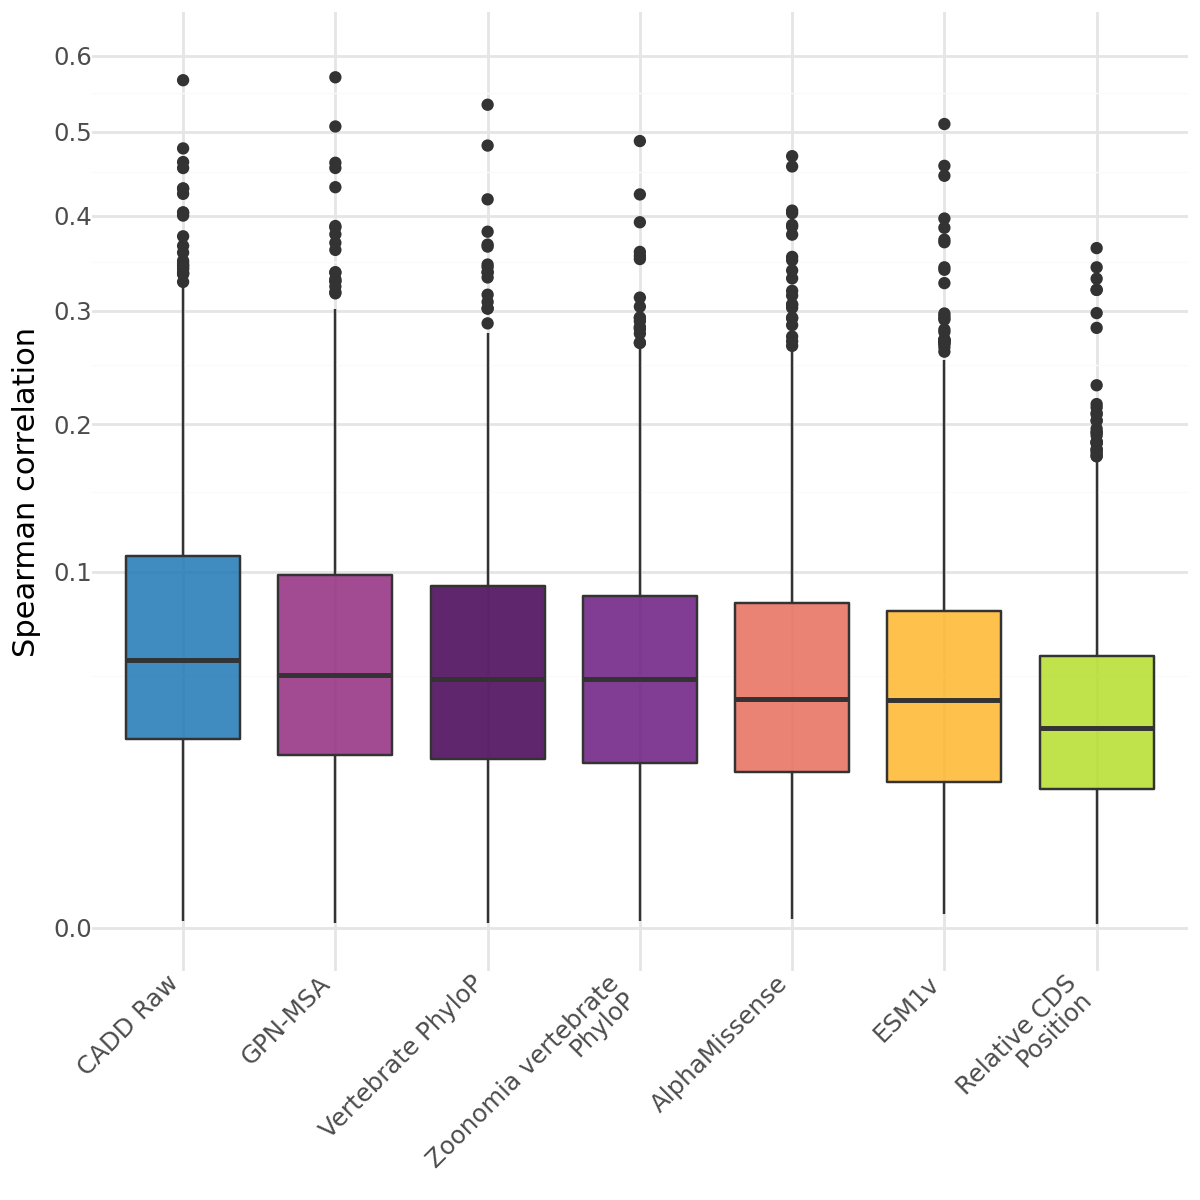

In [9]:
med_df = correlation_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(correlation_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)


# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.85) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_fill_manual(values=color_dict) +   # strict, always from config
    # scale_x_discrete(labels=label_dict) +    # plottable names
    labs(
        x="",
        y="Spearman correlation"
    ) +
    theme(
        figure_size=(6, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [17]:
import itertools
from scipy.stats import wilcoxon

annotations = correlation_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = correlation_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = correlation_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
).filter(pl.col("pval_raw") > 0.05/21)

stats_df

/tmp/ipykernel_315424/872473634.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""zooverphylop""","""verphylop""",3077,2233492.5,0.006446


In [15]:
stats_df.filter(pl.col('VSM_A') == 'am_pathogenicity')

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""am_pathogenicity""","""verphylop""",3077,1.765282e6,2.3019e-34
"""am_pathogenicity""","""zooverphylop""",3077,1.836337e6,4.1557e-27
"""am_pathogenicity""","""relative_cds_position""",3077,2.026621e6,4.4619e-12
"""am_pathogenicity""","""gpn_score""",3077,1.456822e6,2.8170e-76
"""am_pathogenicity""","""esmscoremissense""",3077,2.108998e6,1.5190e-7
"""am_pathogenicity""","""cadd_raw""",3077,1.153322e6,4.5476e-134


## Odds ratio plot

In [165]:
ct_df = pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
).join(
    gene_trait_df[['region', 'phenotype', 'beta', 'beta_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
)

xtm_df = pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")


xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_dircrtd"),
    (pl.col("annotation_score")*pl.col("annotation_dir")).alias("annotation_score_dircrtd")
)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value_dircrtd', 'annotation_score_dircrtd']
]

# Apply the window expressions with .with_columns()
xtm_df = xtm_df.with_columns(rank_expressions).with_columns(
    (pl.col("mean_pheno_value_dircrtd_rank") / pl.col("n_variants")).alias("mean_pheno_value_dircrtd_ptile"),
    (pl.col("annotation_score_dircrtd_rank") / pl.col("n_variants")).alias("annotation_score_dircrtd_ptile")
)

xtm_df = xtm_df.with_columns(
    pl.when(pl.col("mean_pheno_value_dircrtd_ptile") >= 0.9)
    .then(1)
    .otherwise(0)
    .alias("mean_pheno_value_dircrtd_binary"),
)

xtm_df

id,phenotype,n_individuals,mean_pheno_value,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank,n_variants,beta_right,beta_dir,annotation_dir,color,label,mean_pheno_value_dircrtd,annotation_score_dircrtd,mean_pheno_value_dircrtd_rank,annotation_score_dircrtd_rank,mean_pheno_value_dircrtd_ptile,annotation_score_dircrtd_ptile,mean_pheno_value_dircrtd_binary
str,str,u32,f32,str,str,f32,str,str,str,f64,u64,u64,u64,f64,f64,i64,str,str,f64,f64,u64,u64,f64,f64,i32
"""chr1:3478002:T:C""","""cystatin_c_int""",2,-0.99951,"""ENSG00000130762""","""cadd_raw""",3.773917,"""ENSG00000130762""","""ARHGEF16""","""continuous""",-0.037172,32,465,659,-0.037172,-1.0,1,"""#1f77b4""","""CADD Raw""",0.99951,3.773917,628,465,0.952959,0.705615,1
"""chr1:3478002:T:C""","""cystatin_c_int""",2,-0.99951,"""ENSG00000130762""","""esmscoremissense""",-6.885,"""ENSG00000130762""","""ARHGEF16""","""continuous""",-0.037172,32,135,659,-0.037172,-1.0,-1,"""#feb72d""","""ESM1v""",0.99951,6.885,628,525,0.952959,0.796662,1
"""chr1:3478002:T:C""","""cystatin_c_int""",2,-0.99951,"""ENSG00000130762""","""verphylop""",5.713,"""ENSG00000130762""","""ARHGEF16""","""continuous""",-0.037172,32,563,659,-0.037172,-1.0,1,"""#440154""","""Vertebrate PhyloP""",0.99951,5.713,628,563,0.952959,0.854325,1
"""chr1:3478002:T:C""","""cystatin_c_int""",2,-0.99951,"""ENSG00000130762""","""gpn_score""",-4.96,"""ENSG00000130762""","""ARHGEF16""","""continuous""",-0.037172,32,232,659,-0.037172,-1.0,-1,"""#942c80""","""GPN-MSA""",0.99951,4.96,628,427,0.952959,0.647951,1
"""chr1:3478002:T:C""","""cystatin_c_int""",2,-0.99951,"""ENSG00000130762""","""zooverphylop""",4.645,"""ENSG00000130762""","""ARHGEF16""","""continuous""",-0.037172,32,437,659,-0.037172,-1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",0.99951,4.645,628,437,0.952959,0.663126,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr22:40322935:C:G""","""hand_grip_strength_left_int""",1,0.43265,"""ENSG00000100354""","""zooverphylop""",2.976,"""ENSG00000100354""","""TNRC6B""","""continuous""",-0.322835,1073,323,1279,-0.322835,-1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",-0.43265,2.976,207,323,0.161845,0.252541,0
"""chr22:40322935:C:G""","""hand_grip_strength_left_int""",1,0.43265,"""ENSG00000100354""","""verphylop""",0.071,"""ENSG00000100354""","""TNRC6B""","""continuous""",-0.322835,1073,132,1279,-0.322835,-1.0,1,"""#440154""","""Vertebrate PhyloP""",-0.43265,0.071,207,132,0.161845,0.103206,0
"""chr22:40322935:C:G""","""hand_grip_strength_left_int""",1,0.43265,"""ENSG00000100354""","""relative_cds_position""",0.94,"""ENSG00000100354""","""TNRC6B""","""continuous""",-0.322835,1073,1193,1279,-0.322835,-1.0,1,"""#b5de2b""","""Relative CDS Position""",-0.43265,0.94,207,1193,0.161845,0.93276,0


In [166]:
or_df_list = []
for p_itr in tqdm(range(100)):
    ptile_cutoff = 0.5 + p_itr/200

    or_temp = xtm_df.group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        ((pl.col("mean_pheno_value_dircrtd_binary")==1) & (pl.col("annotation_score_dircrtd_ptile")>=ptile_cutoff)).sum().alias("n_dis_above_cutoff"),
        ((pl.col("mean_pheno_value_dircrtd_binary")==0) & (pl.col("annotation_score_dircrtd_ptile")>=ptile_cutoff)).sum().alias("n_not_dis_above_cutoff"),
        (pl.col("mean_pheno_value_dircrtd_binary")==1).sum().alias("total_dis"),
        (pl.col("mean_pheno_value_dircrtd_binary")==0).sum().alias("total_not_dis")
    ).with_columns(
        pl.lit(ptile_cutoff).alias("ptile_cutoff"),
        (pl.col("total_dis")+pl.col("total_not_dis")).alias("n_variants"),
        (((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_not_dis_above_cutoff")+1))/(pl.col("total_dis")/pl.col("total_not_dis"))).alias("odds_ratio"),
    )

    or_df_list.append(or_temp)

or_df = pl.concat(or_df_list)
or_df

100%|██████████| 100/100 [00:32<00:00,  3.06it/s]


annotation,region,phenotype,n_dis_above_cutoff,n_not_dis_above_cutoff,total_dis,total_not_dis,ptile_cutoff,n_variants,odds_ratio
str,str,str,u64,u64,u64,u64,f64,u64,f64
"""cadd_raw""","""ENSG00000167674""","""mean_corpuscular_volume_int""",46,385,87,773,0.5,860,1.081859
"""cadd_raw""","""ENSG00000224389""","""white_blood_cell_leukocyte_cou…",2,17,4,32,0.5,36,1.333333
"""cadd_raw""","""ENSG00000024048""","""body_mass_index_bmi_int""",54,474,106,948,0.5,1054,1.035551
"""esmscoremissense""","""ENSG00000080345""","""trunk_fat_mass_int""",86,767,171,1533,0.5,1704,1.015556
"""relative_cds_position""","""ENSG00000106868""","""reticulocyte_count_int""",27,249,56,494,0.5,550,0.988
…,…,…,…,…,…,…,…,…,…
"""zooverphylop""","""ENSG00000112077""","""high_light_scatter_reticulocyt…",1,1,32,283,0.995,315,8.84375
"""verphylop""","""ENSG00000183914""","""shbg_int""",3,13,312,2798,0.995,3110,2.562271
"""zooverphylop""","""ENSG00000244734""","""reticulocyte_count_int""",1,0,12,103,0.995,115,17.166667


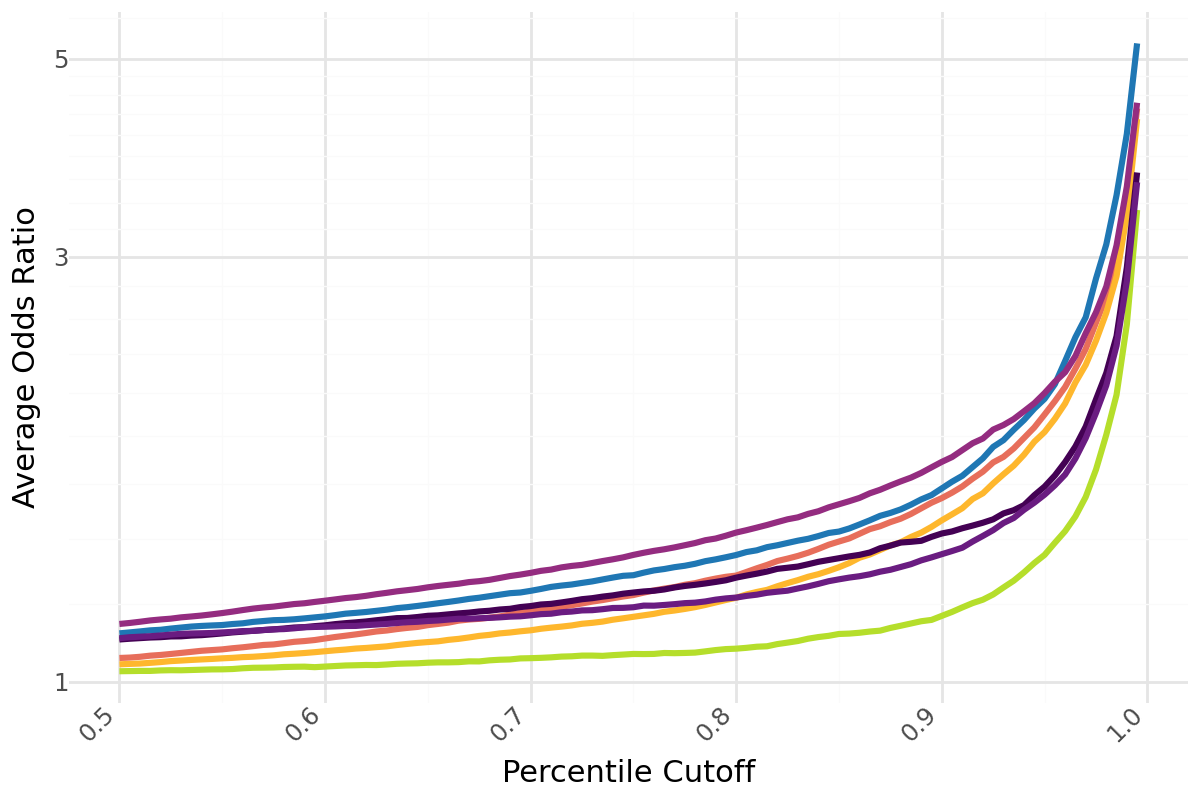

In [178]:
plot_df = or_df.group_by(
    ['annotation', 'ptile_cutoff']
).agg(
    pl.col('odds_ratio').mean()
)

(
    ggplot(plot_df, aes(x='ptile_cutoff', y='odds_ratio', color='annotation')) +
    geom_line(size=1.25) +
    theme_minimal() +
    scale_y_log10() +
    # scale_y_sqrt() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Percentile Cutoff',
        y='Average Odds Ratio'
    ) +
    theme(
        figure_size=(6, 4),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

### Single gene-trait association plot

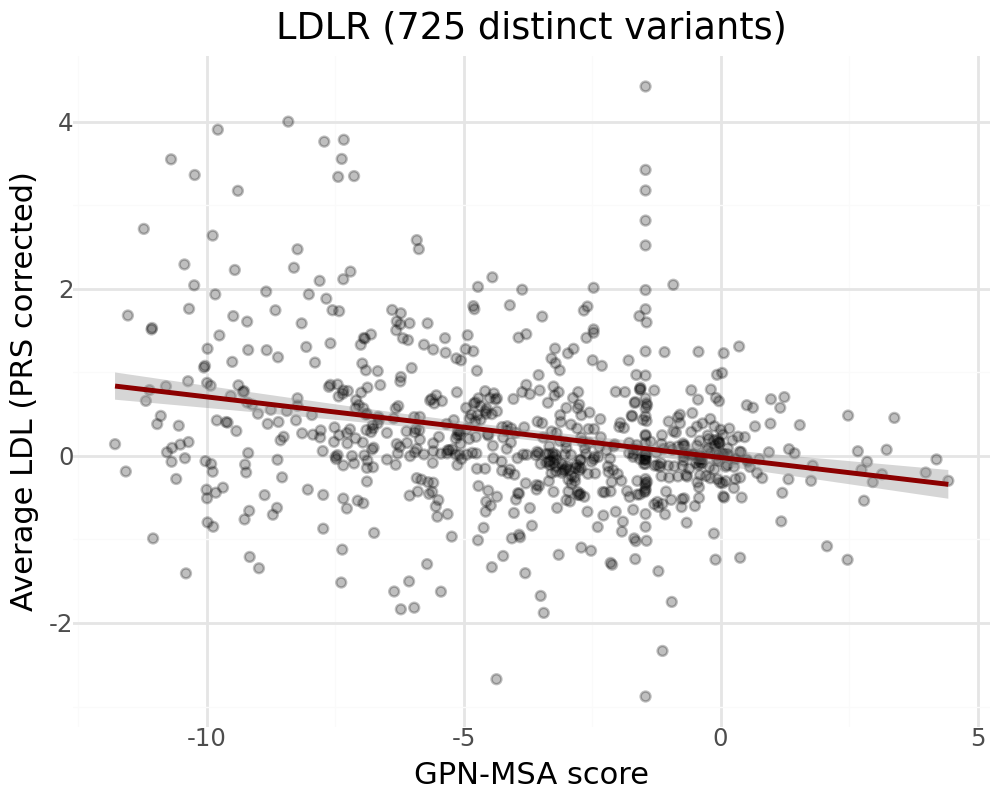

In [151]:
method = 'pearson'
annotation = 'gpn_score'
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'

# Filter your main dataframe
sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

# Compute number of distinct variants per gene/annotation/phenotype if needed
# assuming you have a column like 'variant_id'
num_variants = sc_df.select(pl.col("id").n_unique()).item()

# Get the correct annotation label from annotation_df
annotation_label = anno_config_df.filter(pl.col("annotation") == annotation)["label"][0]

# Scatter plot
(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f'{annotation_label} score',
        # y=f"{phenotype} residual",
        y=f"Average LDL (PRS corrected)",
        title=f"{gene_name} ({num_variants} distinct variants)"
    ) +
    theme(figure_size=(5, 4))
)

### Facet by n_vars

In [25]:
n_cuts = 10
corr_pd['n_var_quantile'] = pd.qcut(corr_pd['n_variants'], n_cuts, labels=[f'{i}' for i in range(1, n_cuts+1)])
corr_pd['n_var_quantile'].value_counts()

n_var_quantile
1     856
3     848
9     848
5     848
6     848
7     848
2     840
4     840
10    840
8     832
Name: count, dtype: int64

/tmp/ipykernel_1043666/3809464156.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


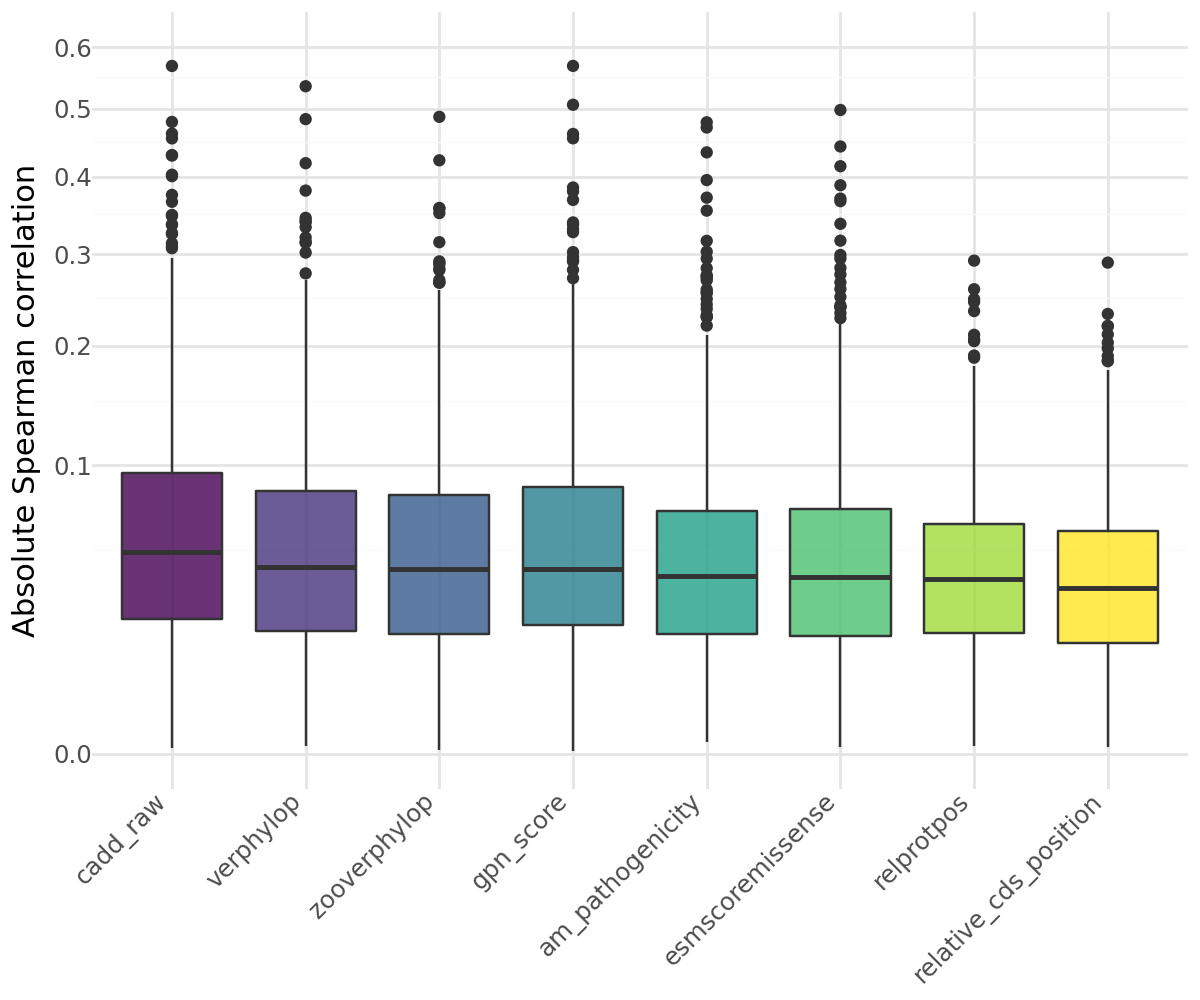

In [28]:
corr_q1 = corr_pd[corr_pd[f'n_var_quantile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

### Facet by LOEUF

In [16]:
# gene_property = 'lof.oe_ci.upper'
gene_property = 'cds_length'

gn = pl.read_csv(
    '/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv', 
    null_values='NA',
    separator='\t'
).filter(
    (pl.col('mane_select') == True) &
    (pl.col('transcript_type') == 'protein_coding')
).with_columns(
    pl.col(gene_property).qcut(10, labels=[f'{i}' for i in range(1, 11)]).alias(f'{gene_property}_decile')
).to_pandas()

gn

,gene,gene_id,transcript,canonical,mane_select,lof_hc_lc.obs,lof_hc_lc.exp,lof_hc_lc.possible,lof_hc_lc.oe,lof_hc_lc.mu,...,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,level,transcript_type,chromosome,cds_length,num_coding_exons,cds_length_decile
0,A1BG,ENSG00000121410,ENST00000263100,True,True,45.0,43.0480,193.0,1.04540,7.063300e-07,...,1.172,-1.166000,-0.635490,[],2,protein_coding,chr19,1485,8,6
1,A1CF,ENSG00000148584,ENST00000373997,True,True,45.0,69.9620,352.0,0.64320,9.547100e-07,...,1.103,0.032727,0.017838,[],2,protein_coding,chr10,1758,11,7
2,A2M,ENSG00000175899,ENST00000318602,True,True,95.0,147.2400,745.0,0.64522,1.344500e-06,...,0.929,3.368800,1.836200,[],2,protein_coding,chr12,4422,36,10
3,A2ML1,ENSG00000166535,ENST00000299698,True,True,146.0,176.0500,881.0,0.82930,1.700700e-06,...,0.996,1.745200,0.951210,[],2,protein_coding,chr12,4362,35,10
4,A3GALT2,ENSG00000184389,ENST00000442999,True,True,41.0,26.5590,110.0,1.54380,3.376300e-07,...,1.753,-7.333400,-3.997000,"[""outlier_mis""]",2,protein_coding,chr1,1020,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17476,None,ENSG00000284024,ENST00000640019,True,True,23.0,33.3410,150.0,0.68984,9.153200e-07,...,1.075,0.716050,0.390280,[],2,protein_coding,chr10,1083,2,4
17477,None,ENSG00000285043,ENST00000338110,True,True,9.0,19.2800,89.0,0.46680,1.504500e-07,...,NaN,NaN,NaN,"[""no_exp_lof"",""no_exp_mis"",""no_exp_syn"",""no_va...",2,protein_coding,chr16,417,4,1
17478,None,ENSG00000286135,ENST00000652090,True,True,0.0,1.4471,8.0,0.00000,2.520600e-08,...,1.067,1.581300,0.861890,[],2,protein_coding,chr10,411,4,1
17479,None,ENSG00000286190,ENST00000568641,True,True,4.0,3.2926,20.0,1.21480,4.915500e-08,...,1.570,-2.406500,-1.311700,[],2,protein_coding,chr17,357,1,1


In [17]:
corr_lf = corr_pd.merge(
    gn[['gene_id', gene_property, f'{gene_property}_decile']], left_on='region', right_on='gene_id', how='left')

corr_lf = corr_lf.dropna()
corr_lf

,annotation,median_abs_corr,region,gene_name,phenotype,n_variants,correlation,abs_corr,gene_id,cds_length,cds_length_decile
0,cadd_raw,0.048888,ENSG00000111266,DUSP16,standing_height_int,493,0.047826,0.047826,ENSG00000111266,1995.0,8
1,esmscoremissense,0.037467,ENSG00000143436,MRPL9,vitamin_d_int,233,0.058965,0.058965,ENSG00000143436,801.0,3
2,cadd_raw,0.048888,ENSG00000177628,GBA,haematocrit_percentage_int,333,-0.057739,0.057739,ENSG00000177628,1608.0,7
3,esmscoremissense,0.037467,ENSG00000142082,SIRT3,mean_platelet_thrombocyte_volume_int,672,-0.043444,0.043444,ENSG00000142082,1197.0,5
4,esmscoremissense,0.037467,ENSG00000169676,DRD5,urate_int,480,-0.004913,0.004913,ENSG00000169676,1431.0,6
...,...,...,...,...,...,...,...,...,...,...,...
8443,gpn_score,0.041156,ENSG00000167895,TMC8,glycated_haemoglobin_hba1c_int,636,0.022287,0.022287,ENSG00000167895,2178.0,8
8444,gpn_score,0.041156,ENSG00000136859,ANGPTL2,standing_height_int,427,0.199656,0.199656,ENSG00000136859,1479.0,6
8445,am_pathogenicity,0.037880,ENSG00000144152,FBLN7,sitting_height_int,420,-0.024669,0.024669,ENSG00000144152,1317.0,5
8446,esmscoremissense,0.037467,ENSG00000166526,ZNF3,haemoglobin_concentration_int,343,0.074992,0.074992,ENSG00000166526,1338.0,6


In [18]:
corr_lf[['region', 'phenotype', f'{gene_property}_decile']].drop_duplicates()[f'{gene_property}_decile'].value_counts(sort=True)

cds_length_decile
10    216
9     145
8     122
6     116
7     109
5      97
4      78
3      59
2      53
1      48
Name: count, dtype: int64

/tmp/ipykernel_1043666/3299248181.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


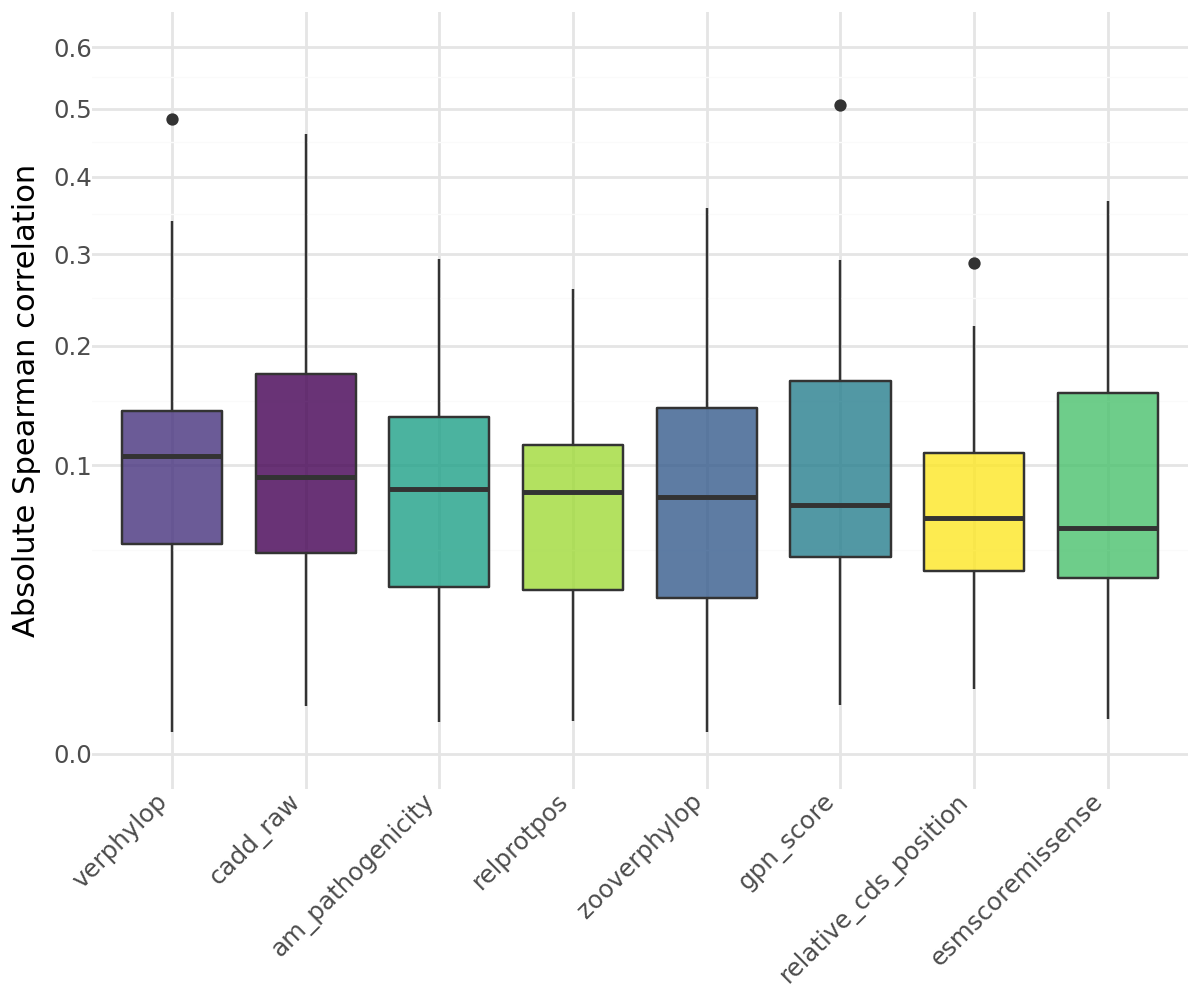

In [19]:
corr_q1 = corr_lf[corr_lf[f'{gene_property}_decile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q1, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

/tmp/ipykernel_1043666/2741533682.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


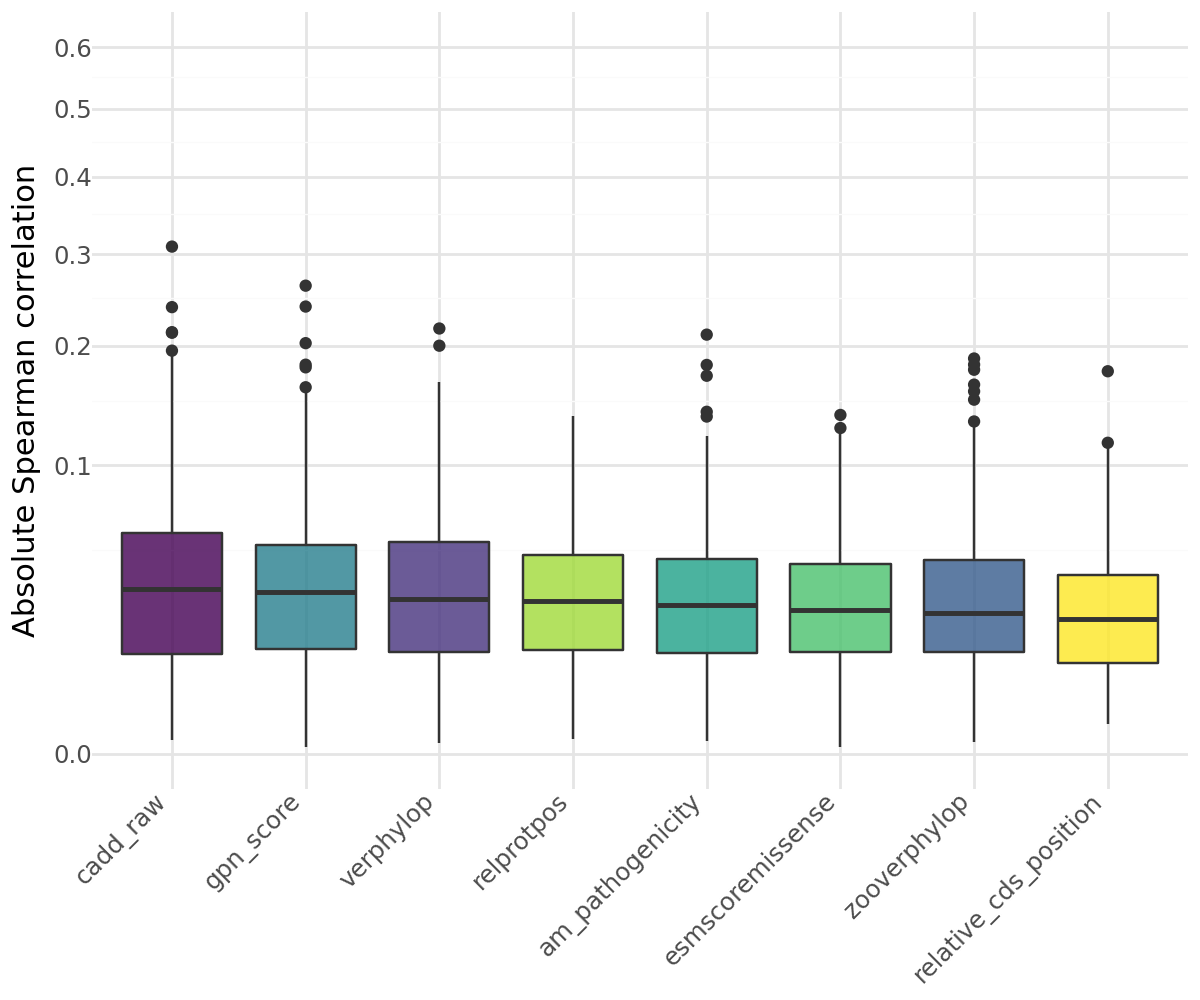

In [20]:
corr_q10 = corr_lf[corr_lf[f'{gene_property}_decile']=='10']

med_df = (
    corr_q10
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q10 = corr_q10.merge(med_df, on='annotation')
order = corr_q10.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q10, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Enrichment of true extremes in predicted extremes

In [ ]:
ct_df = pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
)

xtm_df = pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")

# Restrict to postive associations
# pos_assoc= gene_trait_df.filter(pl.col('beta')>0)
# xtm_df = xtm_df.join(pos_assoc[['region', 'phenotype']], on=['region', 'phenotype'], how='inner')
gene_trait_df = gene_trait_df.with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)
xtm_df = xtm_df.join(gene_trait_df[['region', 'phenotype', 'beta_dir']], on=['region', 'phenotype'], how='inner')

xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_same_dir"),
    (pl.col("annotation_score_rank") / pl.col("n_variants")).alias("annotation_score_ptile")
)

rev_df = xtm_df.filter(pl.col('annotation')=='gpn_score').with_columns(
    (1-pl.col('annotation_score_ptile')).alias('annotation_score_ptile'),
    pl.lit('gpn_score_rev').alias('annotation')
)

xtm_df = pl.concat([xtm_df, rev_df])
xtm_df

id,phenotype,n_individuals,mean_pheno_value,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank,n_variants,beta_dir,mean_pheno_value_same_dir,annotation_score_ptile
str,str,u32,f32,str,str,f32,str,str,str,f64,u32,u32,u32,f64,f64,f64
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""cadd_raw""",-0.694496,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,5,308,-1.0,0.093685,0.016234
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""verphylop""",-2.182,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,7,308,-1.0,0.093685,0.022727
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""esmscoremissense""",0.0,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,187,308,-1.0,0.093685,0.607143
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""am_pathogenicity""",0.0,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,1,308,-1.0,0.093685,0.003247
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""relative_cds_position""",0.8,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,245,308,-1.0,0.093685,0.795455
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr22:36295046:C:T""","""reticulocyte_percentage_int""",12,0.558347,"""ENSG00000100345""","""gpn_score_rev""",-4.02,"""ENSG00000100345""","""MYH9""","""continuous""",-0.453329,1066,835,1284,-1.0,-0.558347,0.349688
"""chr22:36319592:G:A""","""high_light_scatter_reticulocyt…",2,-0.163427,"""ENSG00000100345""","""gpn_score_rev""",-1.28,"""ENSG00000100345""","""MYH9""","""continuous""",-0.428117,476,1110,1284,-1.0,0.163427,0.135514
"""chr22:36322432:G:C""","""high_light_scatter_reticulocyt…",1,-0.132964,"""ENSG00000100345""","""gpn_score_rev""",-2.93,"""ENSG00000100345""","""MYH9""","""continuous""",-0.428117,501,1016,1284,-1.0,0.132964,0.208723


In [567]:
pred_cutoff = 0.1
xtm_df = xtm_df.with_columns(
        (pl.col("annotation_score_ptile") <= pred_cutoff).alias("low_predicted"),
        (pl.col("annotation_score_ptile") >= 1 - pred_cutoff).alias("high_predicted"),
)

enr_df_list = []
for z_alpha in tqdm(range(300)):
    z_score = z_alpha/100
    pr_temp = xtm_df.filter(
        (pl.col("mean_pheno_value") >= z_score)
    ).group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        (pl.count().alias("high_true")),
        (pl.col("high_predicted").sum()).alias("high_correct"),
        
    ).with_columns(
        (pl.col("high_correct") / pl.col("high_true")).alias("high_enrichment"),
        pl.lit(z_score).alias('z_score')
    )

    enr_df_list.append(pr_temp)

enr_df = pl.concat(enr_df_list)
enr_df

  0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_357527/1331981619.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
100%|██████████| 300/300 [00:21<00:00, 13.94it/s]


annotation,region,phenotype,high_true,high_correct,high_enrichment,z_score
str,str,str,u32,u32,f64,f64
"""cadd_raw""","""ENSG00000204301""","""lymphocyte_count_int""",816,84,0.102941,0.0
"""gpn_score""","""ENSG00000024048""","""arm_fat_percentage_right_int""",547,54,0.09872,0.0
"""am_pathogenicity""","""ENSG00000168496""","""leg_predicted_mass_left_int""",132,12,0.090909,0.0
"""cadd_raw""","""ENSG00000244734""","""red_blood_cell_erythrocyte_dis…",62,9,0.145161,0.0
"""am_pathogenicity""","""ENSG00000163631""","""cholesterol_int""",238,30,0.12605,0.0
…,…,…,…,…,…,…
"""gpn_score""","""ENSG00000204520""","""seated_height_int""",1,0,0.0,2.99
"""gpn_score""","""ENSG00000173575""","""lymphocyte_count_int""",11,3,0.272727,2.99
"""esmscoremissense""","""ENSG00000120889""","""mean_corpuscular_volume_int""",2,0,0.0,2.99


In [568]:
annos_to_keep = [
    # 'zoopriphylop',
 'verphylop',
#  'relprotpos',
#  'mamphcons',
 'zooverphylop',
#  'mamphylop',
 'gpn_score',
 'gpn_score_rev',
 'relative_cds_position',
 'esmscoremissense',
#  'priphylop',
 'cadd_raw',
#  'priphcons',
#  'af_ukb',
#  'verphcons',
 'am_pathogenicity'
 ]

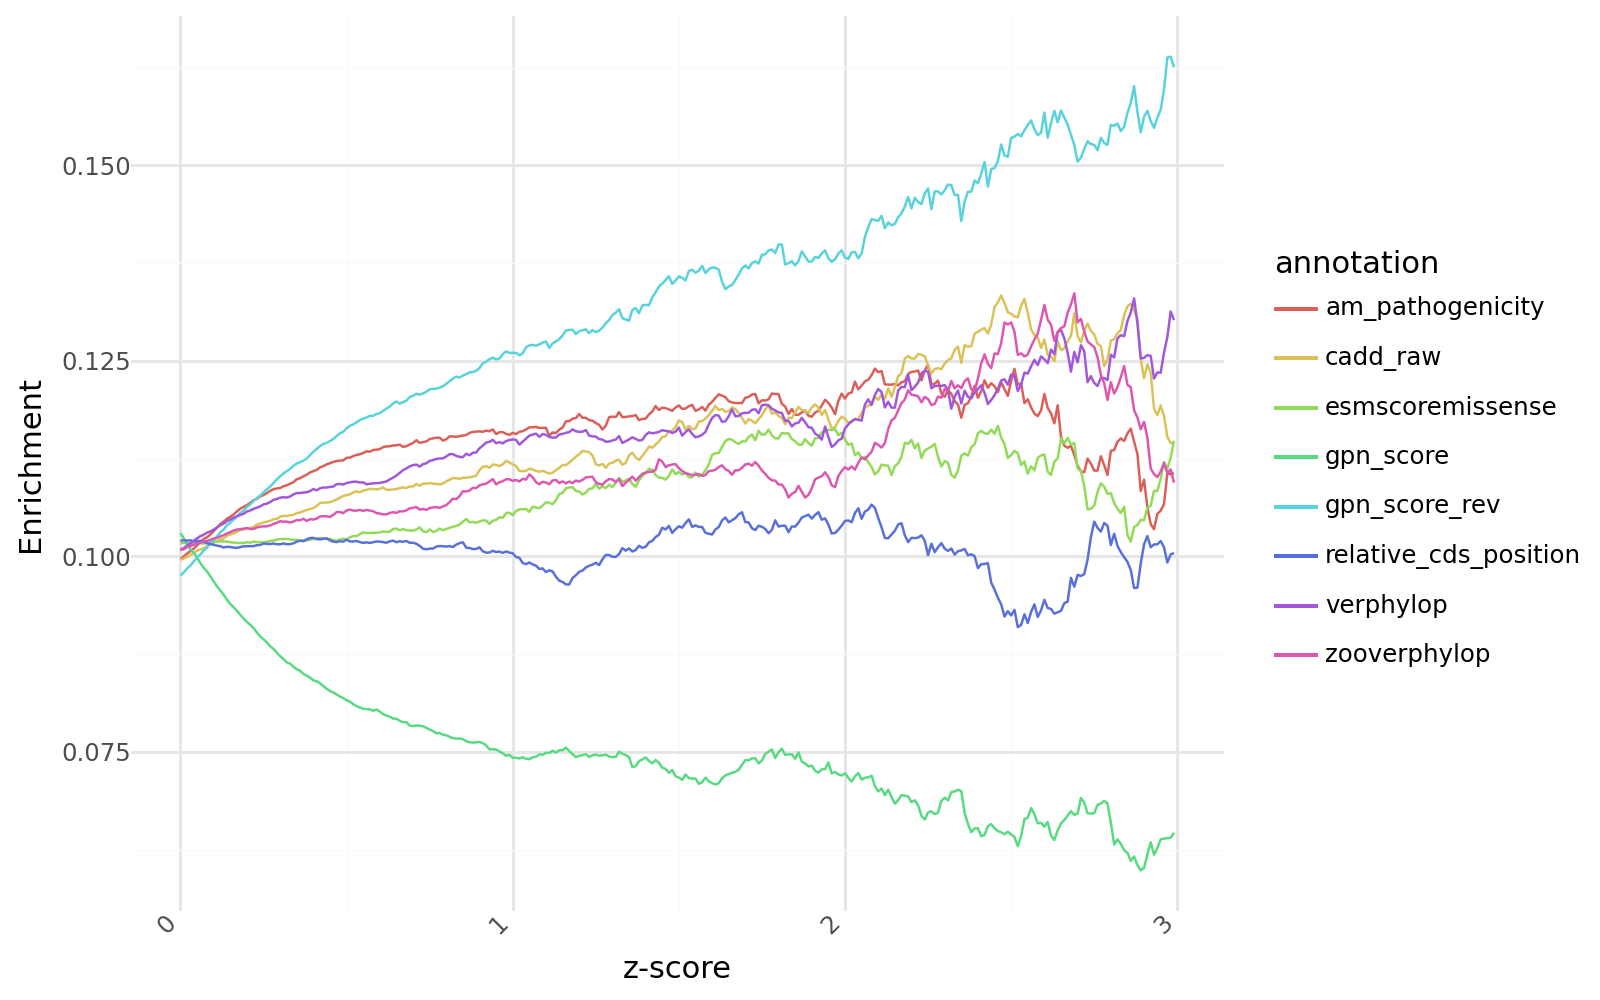

In [569]:
plot_df = enr_df.group_by('annotation', 'z_score').agg(pl.col('high_enrichment').mean())

(
    ggplot(plot_df.filter(pl.col('annotation').is_in(annos_to_keep)), aes(x='z_score', y='high_enrichment', color='annotation')) +
    geom_line() +
    # theme_538() +
    theme_minimal() +
    # scale_color_manual(values=color_dict) +
    labs(
        x='z-score',
        y='Enrichment'
    ) +
    theme(
        figure_size=(8, 5),
        # legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)